### Augmentation 목적
- 여러 샘플에 augmentation이 어떻게 들어가는지
- 같은 이미지에 반복 적용했을 때 얼마나 달라지는지
- 글자/표/레이아웃이 유지되는지
- 너무 과한 augmentation은 아닌지

In [1]:
import os
import sys
from pathlib import Path

ROOT = Path().resolve().parents[2]

os.chdir(ROOT)

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("ROOT:", ROOT)
print("CWD:", Path.cwd())

ROOT: /home/jay/dev/document-type-classification-cv-2
CWD: /home/jay/dev/document-type-classification-cv-2


In [2]:
from typing import cast

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import load_config
from src.dataset.transforms import build_train_transforms

/home/jay/miniconda3/envs/cv_comp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
cfg = load_config(
    base_path="configs/base.yaml",
    data_path="experiments/yoojw/configs/data.yaml",
    train_path="experiments/yoojw/configs/train.yaml",
    inference_path="experiments/yoojw/configs/inference.yaml",
    model_path="configs/model/resnet50.yaml",
)

print(cfg)

namespace(project=namespace(name='document-type-classification', task='multiclass-image-classification', seed=42, num_classes=17, class_names=None), paths=namespace(data_dir='data', raw_dir='data/raw', processed_dir='data/processed', split_dir='data/split', train_csv='data/raw/train.csv', test_csv='data/raw/test.csv', sample_submission_csv='data/raw/sample_submission.csv', train_image_dir='data/raw/train', test_image_dir='data/raw/test', output_dir='experiments/yoojw/outputs', checkpoint_dir='experiments/yoojw/outputs/checkpoints', log_dir='experiments/yoojw/outputs/logs', submission_dir='outputs/submissions'), runtime=namespace(device='auto', amp=True, compile=False, benchmark=False, deterministic=False), logging=namespace(use_wandb=True, wandb_project='document-type-classification', wandb_entity=None, log_interval=50, save_best_only=True, verbose=True), data=namespace(image_col='ID', label_col='target', num_workers=0, pin_memory=False, persistent_workers=False), image=namespace(size=

In [4]:
train_df = pd.read_csv(cfg.paths.train_csv)

print("shape:", train_df.shape)
train_df.head()

shape: (1570, 2)


,ID,target
0,002f99746285dfdd.jpg,16
1,008ccd231e1fea5d.jpg,10
2,008f5911bfda7695.jpg,10
3,009235e4c9c07af5.jpg,4
4,00b2f44967580c74.jpg,16


In [5]:
image_col = cfg.data.image_col
transform = build_train_transforms(cfg)

print("image_col:", image_col)
print("transform ready")

image_col: ID
transform ready


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5354247].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.925403].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3437037].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.186841].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..0.4264924].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2391

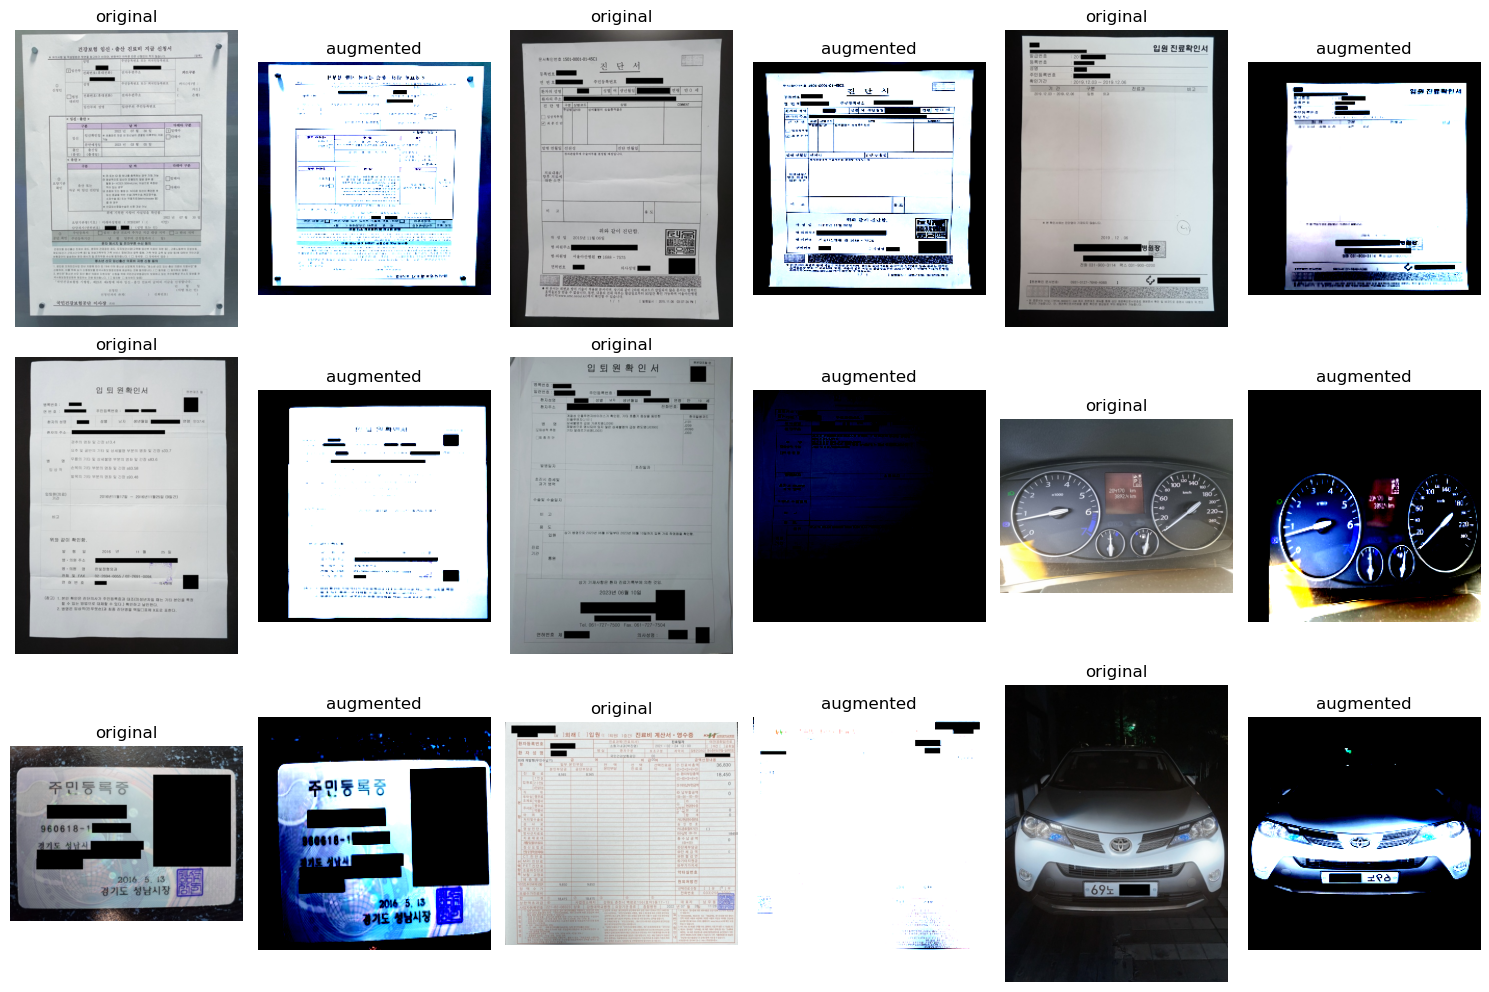

In [6]:
sample_names = train_df[image_col].sample(9, random_state=42).tolist()

plt.figure(figsize=(15, 10))

for i, image_name in enumerate(sample_names):
    image_path = Path(cfg.paths.train_image_dir) / image_name

    raw_image = cv2.imread(str(image_path))
    if raw_image is None:
        continue

    image = cast(np.ndarray, raw_image)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    aug = transform(image=image)["image"].permute(1, 2, 0).numpy()

    plt.subplot(3, 6, 2 * i + 1)
    plt.imshow(image)
    plt.title("original")
    plt.axis("off")

    plt.subplot(3, 6, 2 * i + 2)
    plt.imshow(aug)
    plt.title("augmented")
    plt.axis("off")

plt.tight_layout()
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4831371].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8610326..2.378562].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5354247].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3986642..2.6399999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5354247].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5354247].


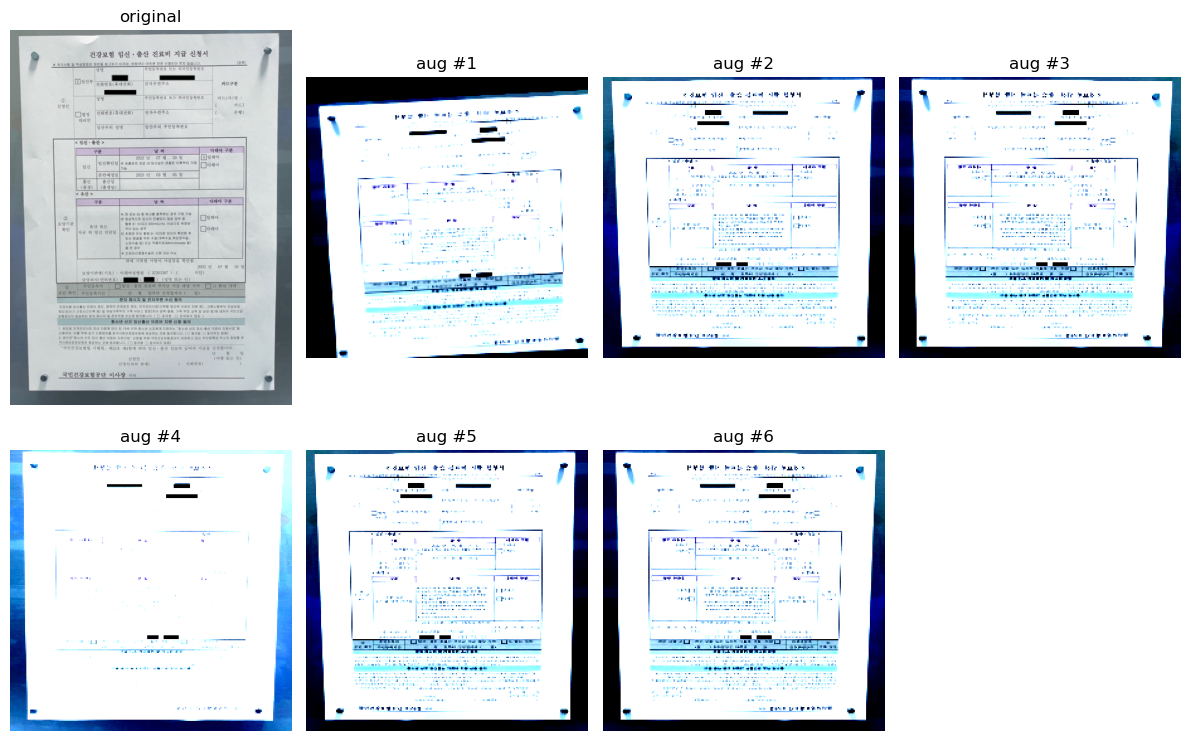

In [9]:
image_name = train_df[image_col].sample(1, random_state=42).iloc[0]
image_path = Path(cfg.paths.train_image_dir) / image_name

raw_image = cv2.imread(str(image_path))
if raw_image is None:
    raise ValueError(f"Failed to load image: {image_path}")

image = cast(np.ndarray, raw_image)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))

plt.subplot(2, 4, 1)
plt.imshow(image)
plt.title("original")
plt.axis("off")

for i in range(6):
    aug = transform(image=image)["image"].permute(1, 2, 0).numpy()

    plt.subplot(2, 4, i + 2)
    plt.imshow(aug)
    plt.title(f"aug #{i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()